# Thermoelectric Materials Dataset
### 3-Dataset Pipeline with Parquet Caching
**Strategy:** Load one dataset at a time → save to parquet → free RAM → repeat → merge at end

| Dataset | Size | What it adds |
|---|---|---|
| `dft_3d` | 75,993 | Core: Seebeck, power factor, bandgap, elastic, dielectric, piezo, EFG |
| `dft_2d` | 1,103 | Same properties for 2D materials |
| `edos_pdos` | 48,469 | Electron + phonon DOS (σ proxy) |



In [1]:
# Cell 1 — Install
%pip install jarvis-tools pandas numpy matplotlib pyarrow -q

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
# Cell 2 — Imports & paths
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import gc
from pathlib import Path
from jarvis.db.figshare import data as jdata

# All files go here
BASE_DIR   = Path.home() / "thermoelectric_dataset"
CACHE_DIR  = BASE_DIR / "cache"      # intermediate parquet files
OUTPUT_DIR = BASE_DIR / "output"     # final CSVs
BASE_DIR.mkdir(parents=True, exist_ok=True)
CACHE_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Cache dir:  {CACHE_DIR}")
print(f"Output dir: {OUTPUT_DIR}")

Cache dir:  C:\Users\Puneetha\thermoelectric_dataset\cache
Output dir: C:\Users\Puneetha\thermoelectric_dataset\output


In [5]:
# Cell 3 — Safe loader: load → parquet → free RAM
# Already-cached datasets are skipped automatically on re-run

import numpy as np

def safe_name(name):
    """Make dataset name safe for filenames."""
    return name.replace(".", "_").replace(" ", "_")

def load_and_cache(name: str, dim_tag: str = None) -> Path:
    pq_path = CACHE_DIR / f"{safe_name(name)}.parquet"

    if pq_path.exists():
        size_mb = pq_path.stat().st_size / 1e6
        print(f"  ✅ Already cached: {name} ({size_mb:.1f} MB) — skipping")
        return pq_path

    print(f"  📂 Loading: {name} ...", flush=True)
    try:
        records = jdata(name)
        df = pd.DataFrame(records)
        df["_source_db"] = name
        if dim_tag:
            df["_dim"] = dim_tag

        # Fix mixed-type columns to avoid parquet errors
        for col in df.columns:
            if df[col].dtype == object:
                converted = pd.to_numeric(df[col], errors="coerce")
                if converted.notna().sum() > 0:
                    # Column is mostly numeric — use numeric version
                    df[col] = converted
                else:
                    # Column is strings — force all to str, replace NaN with None
                    df[col] = df[col].apply(
                        lambda x: str(x) if x is not None and not (isinstance(x, float) and np.isnan(x)) else None
                    )

        df.to_parquet(pq_path, index=False)
        size_mb = pq_path.stat().st_size / 1e6
        print(f"     → {len(df):,} rows, {len(df.columns)} cols, saved {size_mb:.1f} MB")

        del df, records
        gc.collect()
        return pq_path

    except Exception as e:
        print(f"  ⚠  Failed to load '{name}': {e}")
        if pq_path.exists():
            pq_path.unlink()  # delete incomplete parquet so re-run retries
        return None

print("Loader ready.")

Loader ready.


## Step 1 — Load & Cache Each Dataset
Run this cell. Each dataset loads, saves to parquet, then RAM is freed.
**If it crashes or times out — just re-run. Already-cached datasets are skipped.**

In [6]:
# Cell 4 — Load dft_3d (core — ~2 min first run)
print("[1/5] dft_3d")
p1 = load_and_cache("dft_3d", dim_tag="3D")

[1/5] dft_3d
  📂 Loading: dft_3d ...
Obtaining 3D dataset 76k ...
Reference:https://doi.org/10.1016/j.commatsci.2025.114063
Other versions:https://doi.org/10.6084/m9.figshare.6815699
Loading the zipfile...
Loading completed.
     → 75,993 rows, 66 cols, saved 54.8 MB


In [7]:
# Cell 5 — Load dft_2d (~30 sec)
print("[2/5] dft_2d")
p2 = load_and_cache("dft_2d", dim_tag="2D")

[2/5] dft_2d
  📂 Loading: dft_2d ...
Obtaining 2D dataset 1.1k ...
Reference:https://doi.org/10.1016/j.commatsci.2025.114063
Other versions:https://doi.org/10.6084/m9.figshare.6815705


100%|██████████| 8.39M/8.39M [00:14<00:00, 560kiB/s]


Loading the zipfile...
Loading completed.
     → 1,103 rows, 67 cols, saved 13.0 MB


In [8]:
# Cell 6 — Load edos_pdos (~1 min)
print("[3/5] edos_pdos")
p3 = load_and_cache("edos_pdos")

[3/5] edos_pdos
  📂 Loading: edos_pdos ...
Interpolated electronic total dos spin-up dataset 55k...
Reference:https://www.nature.com/articles/s41524-020-00440-1


100%|██████████| 155M/155M [04:50<00:00, 531kiB/s]  


Loading the zipfile...
Loading completed.
     → 55,659 rows, 5 cols, saved 246.8 MB


## Step 2 — Inspect Actual Columns
Before selecting columns, let's see what actually exists in each dataset.

In [12]:
# Cell 9 — Print columns of each cached dataset
for name, path in [("dft_3d", p1), ("dft_2d", p2),
                   ("edos_pdos", p3), ("cfid_3d", p4), ("wtbh_phonon", p5)]:
    if path and path.exists():
        cols = pd.read_parquet(path, columns=None).columns.tolist()
        print(f"\n{'='*50}")
        print(f"{name} — {len(cols)} columns:")
        print(cols)


dft_3d — 66 columns:
['jid', 'spg_number', 'spg_symbol', 'formula', 'formation_energy_peratom', 'func', 'optb88vdw_bandgap', 'atoms', 'slme', 'magmom_oszicar', 'spillage', 'elastic_tensor', 'effective_masses_300K', 'kpoint_length_unit', 'maxdiff_mesh', 'maxdiff_bz', 'encut', 'optb88vdw_total_energy', 'epsx', 'epsy', 'epsz', 'mepsx', 'mepsy', 'mepsz', 'modes', 'magmom_outcar', 'max_efg', 'avg_elec_mass', 'avg_hole_mass', 'icsd', 'dfpt_piezo_max_eij', 'dfpt_piezo_max_dij', 'dfpt_piezo_max_dielectric', 'dfpt_piezo_max_dielectric_electronic', 'dfpt_piezo_max_dielectric_ionic', 'max_ir_mode', 'min_ir_mode', 'n-Seebeck', 'p-Seebeck', 'n-powerfact', 'p-powerfact', 'ncond', 'pcond', 'nkappa', 'pkappa', 'ehull', 'Tc_supercon', 'dimensionality', 'efg', 'xml_data_link', 'typ', 'exfoliation_energy', 'spg', 'crys', 'density', 'poisson', 'raw_files', 'nat', 'bulk_modulus_kv', 'shear_modulus_gv', 'mbj_bandgap', 'hse_gap', 'reference', 'search', '_source_db', '_dim']

dft_2d — 67 columns:
['jid', 'sp

## Step 3 — Select Thermoelectric Columns & Merge

In [13]:
# Cell 10 — Load dft_3d + dft_2d with correct column names

DFT_COLS = [
    # Identity
    "jid", "formula", "spg_symbol", "spg_number", "crys",
    "dimensionality", "_dim", "_source_db",

    # Thermoelectric — BoltzTrap
    "n-Seebeck",       # n-type Seebeck (μV/K)
    "p-Seebeck",       # p-type Seebeck (μV/K)
    "n-powerfact",     # n-type power factor
    "p-powerfact",     # p-type power factor
    "nkappa",          # n-type thermal conductivity κ ← actual column name
    "pkappa",          # p-type thermal conductivity κ
    "ncond",           # n-type electrical conductivity σ
    "pcond",           # p-type electrical conductivity σ

    # Bandgaps
    "optb88vdw_bandgap",
    "mbj_bandgap",
    "hse_gap",

    # Effective masses
    "avg_elec_mass",
    "avg_hole_mass",
    "effective_masses_300K",

    # Thermodynamic
    "formation_energy_peratom",
    "ehull",
    "optb88vdw_total_energy",
    "exfoliation_energy",    # 2D materials

    # Mechanical
    "bulk_modulus_kv",       # actual column name (not kv)
    "shear_modulus_gv",      # actual column name (not gv)
    "elastic_tensor",
    "poisson",               # Poisson ratio

    # Phonons
    "modes",
    "max_ir_mode",
    "min_ir_mode",

    # Dielectric / piezo
    "epsx", "epsy", "epsz",
    "mepsx", "mepsy", "mepsz",
    "dfpt_piezo_max_dielectric",
    "dfpt_piezo_max_dielectric_electronic",
    "dfpt_piezo_max_dielectric_ionic",
    "dfpt_piezo_max_eij",
    "dfpt_piezo_max_dij",

    # Magnetic
    "magmom_oszicar",
    "magmom_outcar",

    # Other
    "slme",
    "spillage",
    "efg",
    "max_efg",
    "density",
    "nat",               # number of atoms
    "Tc_supercon",       # superconducting Tc
    "atoms",             # crystal structure
    "icsd",              # ICSD reference ID
]

def read_with_available_cols(path, wanted_cols):
    all_cols = pd.read_parquet(path, columns=None).columns.tolist()
    use_cols = [c for c in wanted_cols if c in all_cols]
    missing  = [c for c in wanted_cols if c not in all_cols]
    if missing:
        print(f"  Not found: {missing}")
    return pd.read_parquet(path, columns=use_cols)

print("Loading dft_3d...")
df_3d = read_with_available_cols(p1, DFT_COLS)
print(f"dft_3d: {df_3d.shape}")

print("\nLoading dft_2d...")
df_2d = read_with_available_cols(p2, DFT_COLS)
print(f"dft_2d: {df_2d.shape}")

Loading dft_3d...
dft_3d: (75993, 55)

Loading dft_2d...
dft_2d: (1103, 55)


In [14]:
# Cell 11 — Stack 3D + 2D
df_main = pd.concat([df_3d, df_2d], ignore_index=True)
df_main["jid"] = df_main["jid"].astype(str).str.strip()
del df_3d, df_2d
gc.collect()
print(f"Combined 3D + 2D: {df_main.shape}")

Combined 3D + 2D: (77096, 55)


In [15]:
# Cell 12 — Join edos_pdos (electron + phonon DOS)
print("Loading edos_pdos...")
df_dos = pd.read_parquet(p3)
df_dos["jid"] = df_dos["jid"].astype(str).str.strip()

# Only keep columns not already in main
dos_cols = [c for c in df_dos.columns if c not in df_main.columns or c == "jid"]
df_main = df_main.merge(df_dos[dos_cols], on="jid", how="left")

del df_dos
gc.collect()
print(f"After DOS join: {df_main.shape}")

Loading edos_pdos...
After DOS join: (77108, 57)


## Step 4 — Filter ML-Ready Subset & Export

In [17]:
# Cell 15 — Property coverage report (fixed column names)
print(f"Full dataset: {df_main.shape[0]:,} materials × {df_main.shape[1]} columns\n")
print("Coverage of key thermoelectric properties:")

key_cols = [
    "n-Seebeck", "p-Seebeck",
    "n-powerfact", "p-powerfact",
    "nkappa", "pkappa",          # ← actual names
    "ncond", "pcond",            # electrical conductivity
    "optb88vdw_bandgap", "mbj_bandgap", "hse_gap",
    "formation_energy_peratom", "ehull",
    "bulk_modulus_kv", "shear_modulus_gv",  # ← actual names
    "elastic_tensor", "poisson",
    "avg_elec_mass", "avg_hole_mass", "effective_masses_300K",
    "modes", "max_ir_mode", "min_ir_mode",
    "epsx", "epsy", "epsz",
    "dfpt_piezo_max_dielectric", "dfpt_piezo_max_eij",
    "magmom_oszicar", "magmom_outcar",
    "slme", "spillage", "efg", "max_efg",
    "density", "nat", "Tc_supercon",
    "edos_up", "pdos_elast",     # from edos_pdos join
]

for col in key_cols:
    if col in df_main.columns:
        n = df_main[col].notna().sum()
        pct = n / len(df_main) * 100
        print(f"  {col:<40} {n:>7,}  ({pct:.1f}%)")
    else:
        print(f"  {col:<40} NOT FOUND")

Full dataset: 77,108 materials × 57 columns

Coverage of key thermoelectric properties:
  n-Seebeck                                 24,024  (31.2%)
  p-Seebeck                                 24,020  (31.2%)
  n-powerfact                               24,020  (31.2%)
  p-powerfact                               24,020  (31.2%)
  nkappa                                    24,020  (31.2%)
  pkappa                                    24,020  (31.2%)
  ncond                                     24,020  (31.2%)
  pcond                                     24,020  (31.2%)
  optb88vdw_bandgap                         77,108  (100.0%)
  mbj_bandgap                               20,056  (26.0%)
  hse_gap                                      110  (0.1%)
  formation_energy_peratom                  77,108  (100.0%)
  ehull                                     77,108  (100.0%)
  bulk_modulus_kv                           24,927  (32.3%)
  shear_modulus_gv                          24,927  (32.3%)
  elastic_

In [18]:
# Cell 16 — ML-ready subset
seebeck_mask = df_main["n-Seebeck"].notna() | df_main["p-Seebeck"].notna()
df_ml = df_main[seebeck_mask].copy()
print(f"Full dataset:    {len(df_main):,} materials")
print(f"ML-ready subset: {len(df_ml):,} materials (have Seebeck data)")
print(f"Columns:         {df_ml.shape[1]}")

# Show ML subset coverage
print("\nML subset coverage:")
for col in ["n-Seebeck","p-Seebeck","nkappa","pkappa","ncond","pcond",
            "n-powerfact","p-powerfact","bulk_modulus_kv","avg_elec_mass"]:
    if col in df_ml.columns:
        pct = df_ml[col].notna().mean() * 100
        print(f"  {col:<35} {pct:.1f}%")

Full dataset:    77,108 materials
ML-ready subset: 24,024 materials (have Seebeck data)
Columns:         57

ML subset coverage:
  n-Seebeck                           100.0%
  p-Seebeck                           100.0%
  nkappa                              100.0%
  pkappa                              100.0%
  ncond                               100.0%
  pcond                               100.0%
  n-powerfact                         100.0%
  p-powerfact                         100.0%
  bulk_modulus_kv                     48.5%
  avg_elec_mass                       74.8%


In [20]:
# Cell 17 — Clean mixed types then save

def clean_for_parquet(df):
    """Fix any remaining mixed-type columns before saving."""
    df = df.copy()
    for col in df.columns:
        if df[col].dtype == object:
            # Try numeric first
            converted = pd.to_numeric(df[col], errors="coerce")
            if converted.notna().sum() / max(df[col].notna().sum(), 1) > 0.8:
                df[col] = converted
            else:
                # Force to string
                df[col] = df[col].astype(str).replace("nan", None).replace("None", None)
    return df

print("Cleaning columns...")
df_main_clean = clean_for_parquet(df_main)
df_ml_clean   = clean_for_parquet(df_ml)

# Full dataset
full_csv = OUTPUT_DIR / "thermoelectric_full.csv"
full_pq  = OUTPUT_DIR / "thermoelectric_full.parquet"
df_main_clean.to_csv(full_csv, index=False)
df_main_clean.to_parquet(full_pq, index=False)
print(f"Full saved:      {full_csv}")
print(f"                 {df_main_clean.shape[0]:,} rows × {df_main_clean.shape[1]} cols")

# ML-ready subset
ml_csv = OUTPUT_DIR / "thermoelectric_ml_ready.csv"
ml_pq  = OUTPUT_DIR / "thermoelectric_ml_ready.parquet"
df_ml_clean.to_csv(ml_csv, index=False)
df_ml_clean.to_parquet(ml_pq, index=False)
print(f"\nML-ready saved:  {ml_csv}")
print(f"                 {df_ml_clean.shape[0]:,} rows × {df_ml_clean.shape[1]} cols")

Cleaning columns...
Full saved:      C:\Users\Puneetha\thermoelectric_dataset\output\thermoelectric_full.csv
                 77,108 rows × 57 cols

ML-ready saved:  C:\Users\Puneetha\thermoelectric_dataset\output\thermoelectric_ml_ready.csv
                 24,024 rows × 57 cols


## Step 5 — Visualisation

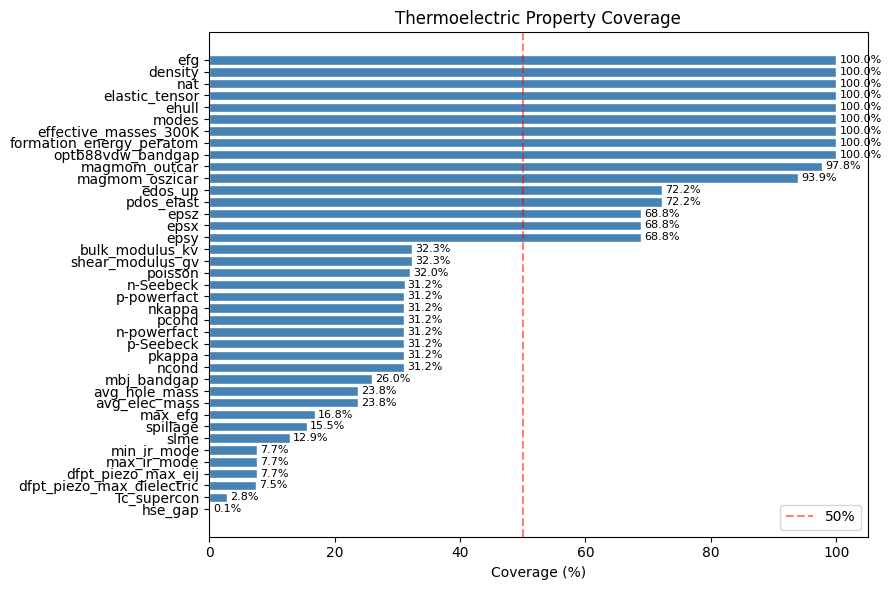

In [21]:
# Cell 18 — Property coverage bar chart
plot_cols = [c for c in key_cols if c in df_main.columns]
coverage  = (df_main[plot_cols].notna().mean() * 100).sort_values()

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(coverage.index, coverage.values, color="steelblue", edgecolor="white")
ax.set_xlabel("Coverage (%)")
ax.set_title("Thermoelectric Property Coverage")
ax.axvline(50, color="red", linestyle="--", alpha=0.5, label="50%")
ax.legend()
for bar, val in zip(bars, coverage.values):
    ax.text(val + 0.5, bar.get_y() + bar.get_height()/2,
            f"{val:.1f}%", va="center", fontsize=8)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "coverage.png", dpi=150)
plt.show()

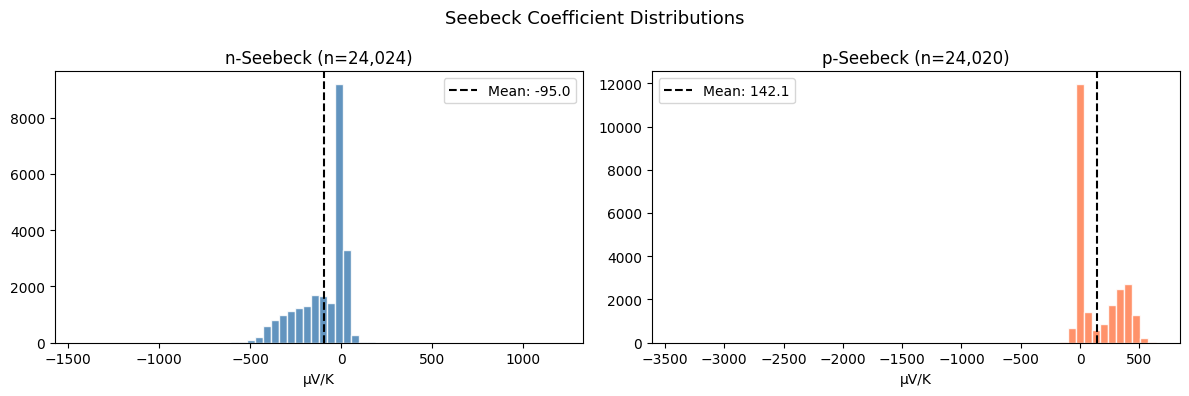

In [22]:
# Cell 19 — Seebeck distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col, color in zip(axes, ["n-Seebeck", "p-Seebeck"], ["steelblue", "coral"]):
    if col not in df_ml.columns:
        continue
    data = pd.to_numeric(df_ml[col], errors="coerce").dropna()
    ax.hist(data, bins=60, color=color, edgecolor="white", alpha=0.85)
    ax.axvline(data.mean(), color="black", linestyle="--", label=f"Mean: {data.mean():.1f}")
    ax.set_title(f"{col} (n={len(data):,})")
    ax.set_xlabel("μV/K")
    ax.legend()
plt.suptitle("Seebeck Coefficient Distributions", fontsize=13)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "seebeck_dist.png", dpi=150)
plt.show()

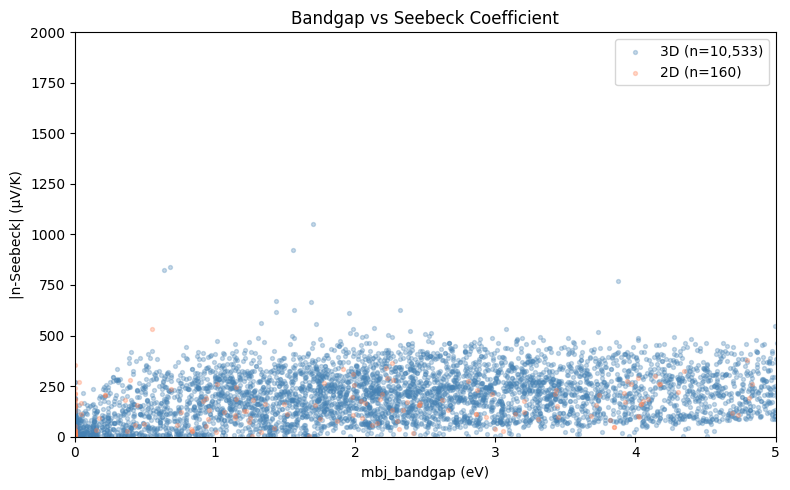

In [23]:
# Cell 20 — Bandgap vs Seebeck scatter (2D vs 3D)
bg_col = "mbj_bandgap" if "mbj_bandgap" in df_ml.columns else "optb88vdw_bandgap"
plot_df = df_ml[[bg_col, "n-Seebeck", "_dim"]].copy()
plot_df["bg"]  = pd.to_numeric(plot_df[bg_col], errors="coerce")
plot_df["see"] = pd.to_numeric(plot_df["n-Seebeck"], errors="coerce").abs()
plot_df = plot_df.dropna(subset=["bg", "see"])

fig, ax = plt.subplots(figsize=(8, 5))
for dim, color in [("3D", "steelblue"), ("2D", "coral")]:
    sub = plot_df[plot_df["_dim"] == dim]
    ax.scatter(sub["bg"], sub["see"], alpha=0.3, s=8, color=color, label=f"{dim} (n={len(sub):,})")
ax.set_xlim(0, 5)
ax.set_ylim(0, 2000)
ax.set_xlabel(f"{bg_col} (eV)")
ax.set_ylabel("|n-Seebeck| (μV/K)")
ax.set_title("Bandgap vs Seebeck Coefficient")
ax.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "bandgap_vs_seebeck.png", dpi=150)
plt.show()

## Step 6 — Material Lookup

In [ ]:
# Cell 21 — Lookup any material by formula
def lookup(formula: str) -> pd.DataFrame:
    results = df_main[df_main["formula"].str.lower() == formula.lower()]
    if results.empty:
        results = df_main[df_main["formula"].str.contains(formula, case=False, na=False)]
    print(f"Found {len(results)} entries for '{formula}'")
    # Show only non-null columns
    non_null_cols = [c for c in results.columns if results[c].notna().any()]
    return results[non_null_cols].T

# Famous thermoelectric
lookup("Bi2Te3")

In [ ]:
# Cell 22 — Change this to look up any material
MATERIAL = "PbTe"   # ← change here
lookup(MATERIAL)

In [ ]:
# Cell 23 — Summary
print("=" * 55)
print("FINAL DATASET SUMMARY")
print("=" * 55)
print(f"Total materials:          {len(df_main):,}")
if "_dim" in df_main.columns:
    print(f"  3D:                     {(df_main['_dim']=='3D').sum():,}")
    print(f"  2D:                     {(df_main['_dim']=='2D').sum():,}")
print(f"ML-ready (has Seebeck):   {len(df_ml):,}")
print(f"Total columns:            {df_main.shape[1]}")
print(f"\nFiles saved to: {OUTPUT_DIR}")
for f in OUTPUT_DIR.iterdir():
    print(f"  {f.name}  ({f.stat().st_size/1e6:.1f} MB)")